In [ ]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import random

# **Setting 1**

$X = \mu + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \ \sigma^2I)$

Randomly select $j \in [p]$

Hypothesis:
$H_0: \mu_j = 0, \quad H_1: \mu_j \neq 0$

Test statistisc: $T = x_j = \eta_j^TX$ <br><br>

## Nhận định

Sau khi hist tất cả giá trị của p-value lên, ta được kết quả là 1 phân phối đều !?

Ta sử dụng kết quả của định lý sau https://en.wikipedia.org/wiki/Probability_integral_transform

*Xét $X$ là biến ngẫu nhiên tuân theo phân phối liên tục với hàm phân phối tích lũy là $F_X$. Ta có được biến ngẫu nhiên $Y$ được định nghĩa là $Y := F_X(X)$ tuân theo phân phối đều trong đoạn từ 0 đến 1 : $\ \ Y \sim U(0, \ 1)$*

Thật vậy, ta có giá trị của p-value được tính bằng $2 * min(F_X(x), \ 1 - F_X(x))$

Xét $P = h(U) = h(F_X(X)),$ với $\ h(u) = 2 * min(u, \ 1 - u)$

Với $0 <= \alpha <= 1,$
 $$
\begin{align}
P(P \le \alpha)
   &= P\!\left( 2 \min(U, \ 1 - U) \le \alpha \right) \\
   &= P\!\left( \min(U, \ 1 - U) \le \tfrac{\alpha}{2} \right) \\
   &= P(U \le \tfrac{\alpha}{2}) + P(U \ge 1 - \tfrac{\alpha}{2}) \\
   &= P(U \le \tfrac{\alpha}{2}) + 1 - P(U \le 1 - \tfrac{\alpha}{2}) \\
   &= \tfrac{\alpha}{2} + 1 - (1 - \tfrac{\alpha}{2}) \\
   &= \alpha
\end{align}
$$

Suy ra ta có được $P$ tuân theo phân phối đều


[np.float64(0.30835005830477424), np.float64(0.2918814158195858), np.float64(0.7588290289532289), np.float64(0.2966707202145231), np.float64(0.21484635754071135), np.float64(0.38142089091970943), np.float64(0.909116575186186), np.float64(0.45407524524848375), np.float64(0.5578758121904337), np.float64(0.109626224055877), np.float64(0.27637695031347487), np.float64(0.519581598982038), np.float64(0.46985569028633467), np.float64(0.6338883879873141), np.float64(0.785843818799282), np.float64(0.33951756639681596), np.float64(0.7817484536803954), np.float64(0.05500897679638896), np.float64(0.8189804275959571), np.float64(0.9420188138269843), np.float64(0.4763061569581395), np.float64(0.8848427746899619), np.float64(0.2197284221594068), np.float64(0.3807188062979012), np.float64(0.7376600880784431), np.float64(0.13329964788072107), np.float64(0.8109019475831518), np.float64(0.5021679104963614), np.float64(0.6989101500954411), np.float64(0.28021728608849095), np.float64(0.097915284375238), np

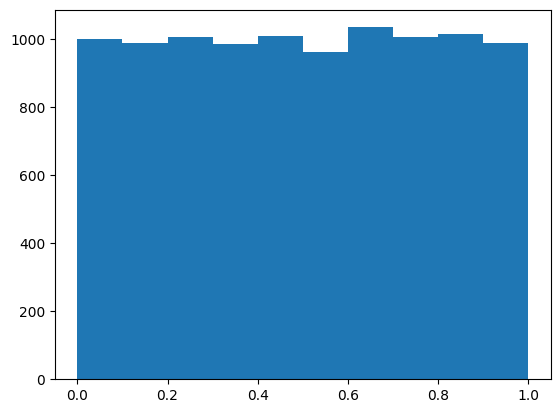

In [ ]:
def generate(n: int):
    X = np.random.normal(loc=0 , scale=5, size=(n , 1))
    err = np.random.normal(loc = 0 , scale=5 , size=(n , 1))
    return X + err

def get_p_value(X):
    cdf = norm.cdf(X[0][0] , loc = 0, scale=np.sqrt(50))
    return 2 * min(cdf , 1 - cdf)

def test():
    n_samples = 100
    ITERATIONS = 10000
    list_p_values = []

    for i in range(ITERATIONS):
        X = generate(n_samples)

        etaT = np.zeros((1 , n_samples))
        j = random.randint(0 , n_samples - 1)
        etaT[0][j] = 1

        p_value = get_p_value(np.dot(etaT , X))
        list_p_values.append(p_value)

    print(list_p_values)
    plt.hist(list_p_values , bins=10)
    plt.show()

test()

# **Setting 2**

$y = \mu + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \Sigma)$

Randomly select $j \in [p]$

Hypothesis: $H_0: \beta_j^* = 0, \quad H_1: \beta_j^* \neq 0$

Test statistics: $T = \hat{\beta_j} = [(X^TX)^{-1}X^Ty]_j = \eta_j^Ty $ <br><br>


## Nhận định
Do hàm mật độ xác suất lúc này được tính theo công thức
```python
cdf = norm.cdf(etaTy_j, loc=0, scale=np.sqrt(np.dot(eta.T, eta)[0][0]))
```

Mặt khác, với $\ X \sim (\mu, \ \sigma), \ $ ta luôn có thể đưa $X$ về dạng $Z \sim N(0, 1)$ theo $Z = \dfrac{X - \mu}{\sigma}$

Do đó chúng ta có thể chứng minh tương tự như ở *Setting 1*



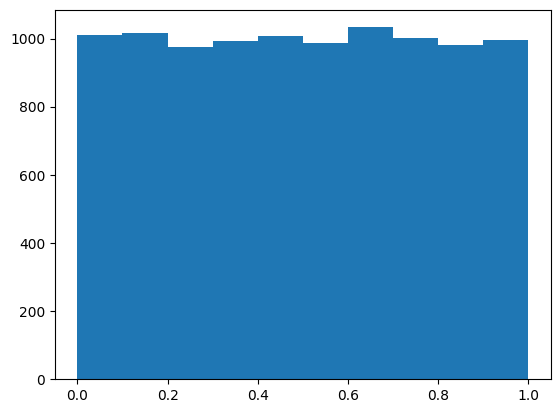

In [ ]:
def generate(n , p):
    true_beta = np.zeros((1 , p))
    X = np.random.normal(loc=0 , scale=1 , size=(n , p))
    err = np.random.normal(loc=0 , scale=1 , size=(n , 1))
    true_y = np.dot(X , true_beta.T)
    y = true_y + err

    return X , y , true_y

def get_p_value(n , p , X , y):
    XTX = np.dot(X.T , X)
    XTXinv = np.linalg.inv(XTX)
    XTXinvXT = np.dot(XTXinv , X.T)
    t_stat = np.dot(XTXinvXT , y)

    eta = XTXinvXT.T
    etaTy = np.dot(eta.T , y)

    e = np.zeros((p , 1))
    j = random.randint(0 , p - 1)
    e[j][0] = 1

    etaTy_j = np.dot(etaTy.T , e)

    cdf = norm.cdf(etaTy_j[0][0] , loc=0, scale=np.sqrt(np.dot(eta.T, eta)[0][0]))
    return 2 * min(cdf , 1 - cdf)

def run():
    ITERATIONS = 10000
    list_p_value = []

    for i in range(ITERATIONS):
        n , p = 500 , 20
        X , y , true_y = generate(n , p)

        list_p_value.append(get_p_value(n , p , X , y))

    plt.hist(list_p_value)
    plt.show()

run()

# **Setting 3**

$X = \mu + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \Sigma)$

$j = \arg\max \{ \;x_i\;\}$

Hypothesis:
$H_0: \mu_j = 0, \quad H_1: \mu_j \neq 0$

Test statistisc: $T = x_j = \eta_j^TX$ <br><br>

## Nhận định
Khi ta chọn $T = x_j$ dựa trên $j = \arg\max \{ \;x_i\;\}$ thì $ \ T \ $ lúc này có xu hướng lệch nhiều về phần đuôi bên phải của phân phối chuẩn

Do đó phần lớn các p-value sẽ nằm ở phần bác bỏ $H_0$, khi hist p-value lên ta không còn được kết quả là 1 phân phối đều

[np.float64(0.027916619018658606), np.float64(0.010761493832309066), np.float64(0.0017754699268772711), np.float64(0.04421212190506352), np.float64(0.003531898002735012), np.float64(0.022961540475085584), np.float64(0.010908519817379059), np.float64(0.010825475746406577), np.float64(0.008748691839967515), np.float64(0.0010428931838790678), np.float64(0.031019590038208422), np.float64(0.028114686805427835), np.float64(0.039178747278759474), np.float64(0.04958371931575423), np.float64(0.028539051447996622), np.float64(0.014336037524005807), np.float64(0.021386581651458902), np.float64(0.0719152384246291), np.float64(0.060460786611136186), np.float64(0.00335556369588752), np.float64(0.03457970887669526), np.float64(0.04680987932722758), np.float64(0.008508256375767909), np.float64(0.07570536868267963), np.float64(0.026952556334858935), np.float64(0.0013628227345989785), np.float64(0.014263636422809256), np.float64(0.007372716970151183), np.float64(0.014787620875860386), np.float64(0.00163

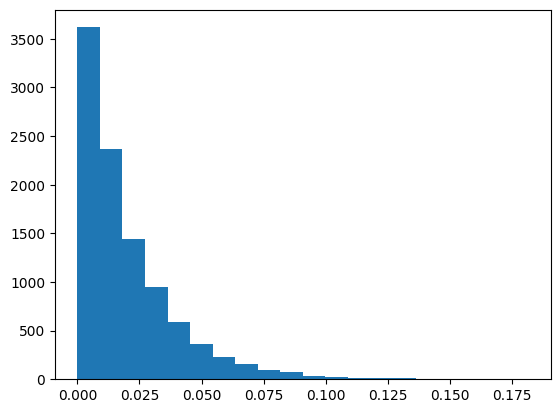

In [ ]:
def generate(n: int):
    X = np.random.normal(loc=0 , scale=5, size=(n , 1))
    err = np.random.normal(loc = 0 , scale=5 , size=(n , 1))
    return X + err

def get_p_value(X):
    cdf = norm.cdf(X[0][0] , loc = 0, scale=np.sqrt(50))
    return 2 * min(cdf , 1 - cdf)

def test():
    n_samples = 100
    ITERATIONS = 10000
    list_p_values = []

    for i in range(ITERATIONS):
        X = generate(n_samples)

        etaT = np.zeros((1 , n_samples))
        j = np.argmax(X)
        etaT[0][j] = 1

        p_value = get_p_value(np.dot(etaT , X))
        list_p_values.append(p_value)

    print(list_p_values)
    plt.hist(list_p_values , bins=20)
    plt.show()

test()

# **Setting 4**

$y = \mu + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \Sigma)$

$j = \arg\max \{ \;\beta_i\;\}$

Hypothesis: $H_0: \beta_j^* = 0, \quad H_1: \beta_j^* \neq 0$

Test statistics: $T = \hat{\beta_j} = [(X^TX)^{-1}X^Ty]_j = \eta_j^Ty $ <br><br>


## Nhận định
Chứng minh tương tự như ở *Setting 2* và *Setting 3*

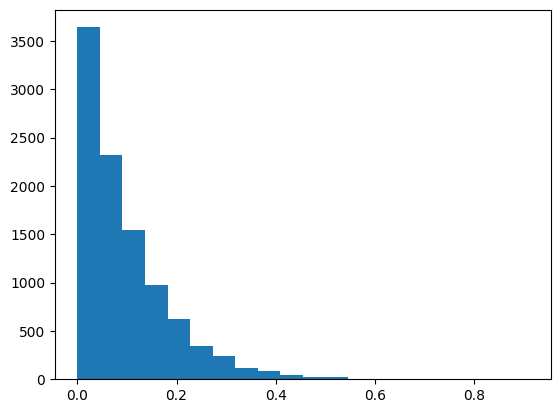

In [ ]:
def generate(n , p):
    true_beta = np.zeros((1 , p))
    X = np.random.normal(loc=0 , scale=1 , size=(n , p))
    err = np.random.normal(loc=0 , scale=1 , size=(n , 1))
    true_y = np.dot(X , true_beta.T)
    y = true_y + err

    return X , y , true_y

def get_p_value(n , p , X , y):
    XTX = np.dot(X.T , X)
    XTXinv = np.linalg.inv(XTX)
    XTXinvXT = np.dot(XTXinv , X.T)
    t_stat = np.dot(XTXinvXT , y)

    eta = XTXinvXT.T
    etaTy = np.dot(eta.T , y)

    e = np.zeros((p , 1))
    j = np.argmax(etaTy)
    e[j][0] = 1

    etaTy_j = np.dot(etaTy.T , e)

    cdf = norm.cdf(etaTy_j[0][0] , loc=0, scale=np.sqrt(np.dot(eta.T, eta)[0][0]))
    return 2 * min(cdf , 1 - cdf)

def run():
    ITERATIONS = 10000
    list_p_value = []

    for i in range(ITERATIONS):
        n , p = 500 , 20
        X , y , true_y = generate(n , p)

        list_p_value.append(get_p_value(n , p , X , y))

    plt.hist(list_p_value , bins=20)
    plt.show()

run()